# 05 — Container Loading (multi-contenedor + peso)

> **Catálogo homogéneo `showcase_master_catalog.json`** — mismos SKUs P1–P5 en 3D-BPP, Container Loading y Single Container. Cada tipo usa una **instancia showcase** compleja donde el benchmark **diferencia** los algoritmos del grupo.

**Instancia:** `showcase_container_loading_instance.json` — catálogo homogéneo P1–P5 (30 uds) en C1/C2.

El servicio prioriza **peso** y **distribución** entre contenedores.
El benchmark (perfil `constructive`) contrasta tres estrategias:
- `single_container_constructive` — densifica un contenedor (alta util, menos piezas)
- `weight_aware_container_loading` — distribuye y empaca más piezas
- `extreme_points_3d` — heurística geométrica multi-contenedor


In [1]:
# Configuración del entorno (ejecutar primero)
%matplotlib inline

import sys
from pathlib import Path
import matplotlib.pyplot as plt

_cwd = Path.cwd().resolve()
for _candidate in [_cwd, *_cwd.parents]:
    _nb = _candidate / "notebooks"
    if (_nb / "_shared" / "loaders.py").exists():
        if str(_nb) not in sys.path:
            sys.path.insert(0, str(_nb))
        break
else:
    raise RuntimeError("No se encontró notebooks/_shared. Abre el notebook desde packing-services/.")

from _shared.loaders import setup_paths
ROOT = setup_paths(_cwd)
from _shared import display, viz, runners

plt.rcParams.update({"figure.dpi": 110, "font.size": 11})
print(f"Proyecto: {ROOT}")


Proyecto: /home/edmundo/packing-services


In [2]:
from _shared.loaders import load_showcase_instance, build_container_loading_request
from packing_services.schemas.requests import ContainerLoadingRequest

instance = load_showcase_instance('CONTAINER_LOADING')
data = build_container_loading_request(instance)
request = ContainerLoadingRequest(**data)
display.show_problem_overview(instance)
print('Algoritmo:', data['algorithm']['name'])


Contenedores disponibles:


ID,Largo,Ancho,Alto,Peso máx,Volumen
C1,100,80,80,500,640000
C2,100,80,80,500,640000


Catálogo de piezas (ítems):


Tipo,Largo,Ancho,Alto,Peso,Cantidad
P1,50,40,30,6,6
P2,60,30,40,7,5
P3,45,45,25,5,4
P4,30,25,55,4,5
P5,20,20,20,2,10


Restricciones activas: non_overlap, containment, allow_rotation, max_weight
Algoritmo: weight_aware_container_loading


2026-07-12 15:37:15,012 | INFO    | packing_services.services.container_loading_service | container-loading request_id=showcase-cl-001 algorithm=weight_aware_container_loading items=30 containers=2


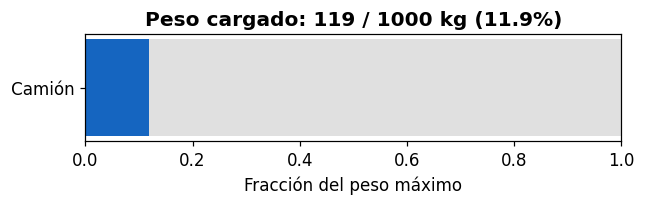

In [3]:
solution = runners.run_container_loading(data)
display.show_kpis(solution.metrics, valid=solution.validation_report.is_valid,
    algorithm=solution.algorithm_name, extra={'Peso cargado': f'{solution.metrics.loaded_weight:.0f} kg'})
max_w = request.containers[0].max_weight or 500
fig = viz.plot_weight_bar(solution.metrics.loaded_weight, max_w * len(request.containers))
plt.show()


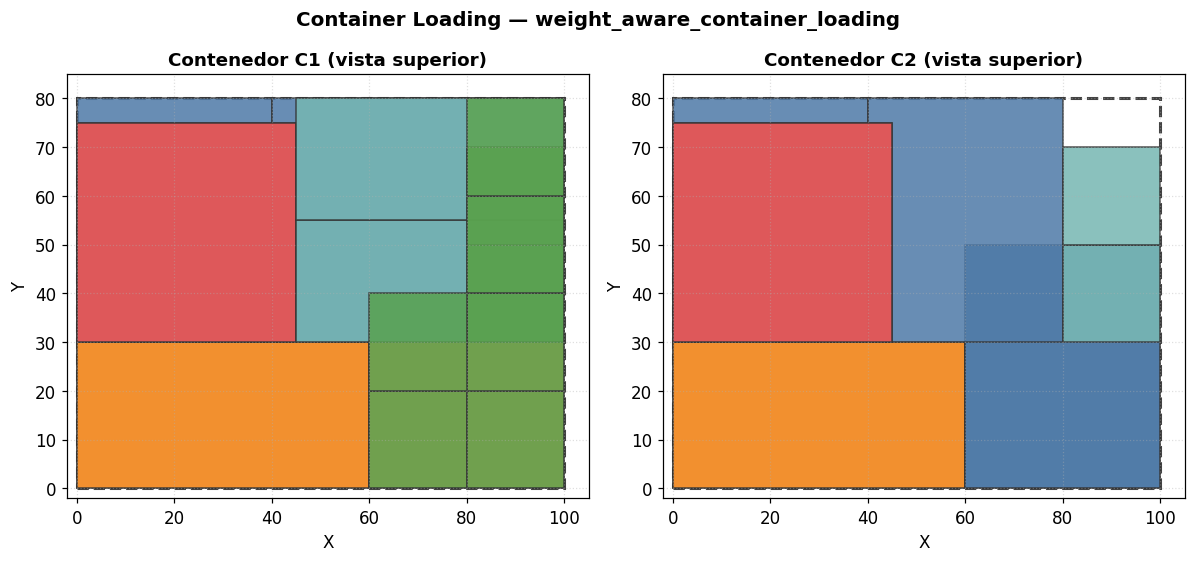

In [4]:
fig = viz.plot_all_container_views(solution, request.containers, title_prefix='Container Loading')
if fig: plt.show()


═══ BENCHMARK HOMOGÉNEO (Container Loading) ═══
Motores comparables — Container Loading:


#,Algoritmo,Nombre,Opcional
1,single_container_constructive,Single Container Constructive,No
2,weight_aware_container_loading,Weight-aware Container Loading,No
3,extreme_points_3d,Extreme Points (multi-contenedor),No


2026-07-12 15:37:15,564 | INFO    | packing_services.services.container_loading_service | container-loading request_id=benchmark-cl-001 algorithm=single_container_constructive items=30 containers=2


2026-07-12 15:37:15,578 | INFO    | packing_services.services.container_loading_service | container-loading request_id=benchmark-cl-001 algorithm=weight_aware_container_loading items=30 containers=2


2026-07-12 15:37:15,611 | INFO    | packing_services.services.container_loading_service | container-loading request_id=benchmark-cl-001 algorithm=extreme_points_3d items=30 containers=2


Nota: weight_aware ~27 emp. vs single_container ~17 (alta util) vs extreme_points ~22
Benchmark — Container Loading


Posición,Algoritmo,Utilización,Empacados,Sin empacar,Válida,Tiempo (s)
1,weight_aware_container_loading,84.8%,27,3,Sí,0.0307
2,extreme_points_3d,65.7%,22,8,Sí,0.0176
3,single_container_constructive,87.5%,17,13,Sí,0.0124


Ranking Container Loading: (1) válidas; (2) menor items_unpacked; (3) mayor volume_utilization; (4) menor tiempo.


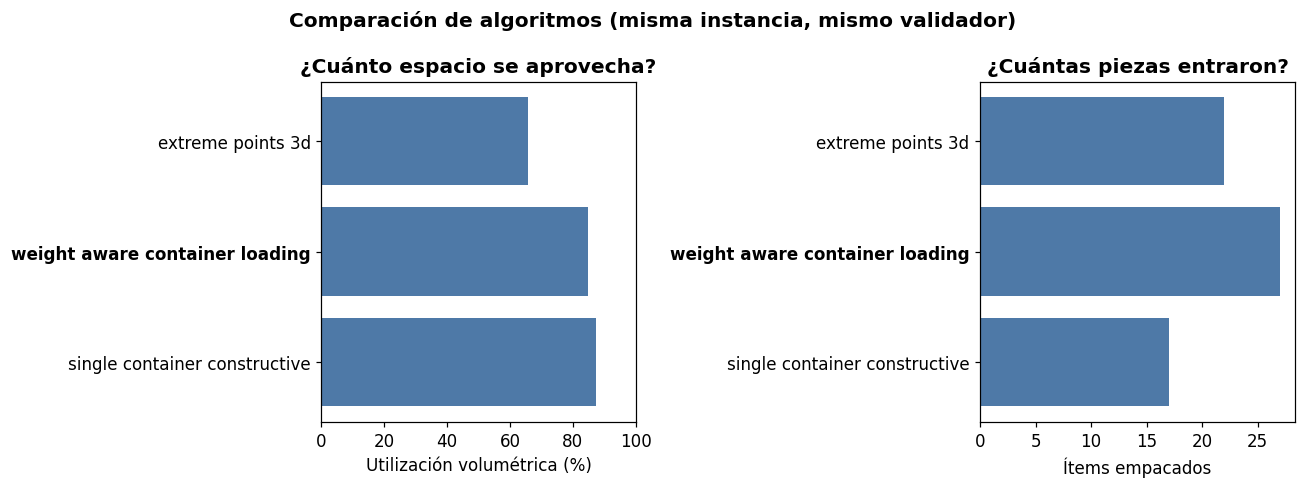

BenchmarkResponse(request_id='benchmark-cl-001', results=[BenchmarkEngineResult(engine='single_container_constructive', status='partial', is_valid=True, metrics=Metrics(volume_utilization=0.875, waste_volume=0.125, containers_used=1, items_packed=17, items_unpacked=13, packed_volume=560000.0, unpacked_volume=648750.0, total_item_volume=1208750.0, loaded_weight=67.0, execution_time_seconds=0.01239, constraint_violations=0), validation_report=ValidationReport(is_valid=True, violations=[]), solution=PackingSolution(request_id='benchmark-cl-001', status=<SolutionStatus.PARTIAL: 'partial'>, problem_type=<ProblemType.CONTAINER_LOADING: 'CONTAINER_LOADING'>, algorithm_name='single_container_constructive', packed_items=[PackedItem(item_id='P2#1', container_id='C1', position=Point3D(x=0.0, y=0.0, z=0.0), orientation=Orientation(length=60.0, width=30.0, height=40.0), weight=7.0), PackedItem(item_id='P2#2', container_id='C1', position=Point3D(x=0.0, y=0.0, z=40.0), orientation=Orientation(length=

In [5]:
print('═══ BENCHMARK HOMOGÉNEO (Container Loading) ═══')
display.run_and_show_showcase_benchmark('CONTAINER_LOADING', instance)


**Siguiente:** `06_single_container_loading.ipynb`
